# 🚗 Notebook 01 — Découverte de l'environnement HighwayEnv

Ce notebook permet de comprendre comment fonctionne l'environnement `highway-fast-v0` avant l'entraînement.

**Objectifs :**
- Créer et réinitialiser l'environnement
- Comprendre l'espace d'observation (ce que voit l'IA)
- Comprendre l'espace d'actions (ce que peut faire l'IA)
- Faire tourner un agent aléatoire pour voir le comportement de base

## 1. Installation & Imports

In [1]:
# Si les dépendances ne sont pas encore installées :
# !pip install highway-env stable-baselines3 gymnasium matplotlib pandas

import gymnasium as gym
import highway_env
import numpy as np
import matplotlib.pyplot as plt

print('✅ Imports OK')

✅ Imports OK


## 2. Créer l'environnement

In [2]:
# On crée l'environnement sans rendu visuel (plus rapide pour les tests)
env = gym.make('highway-fast-v0')
obs, info = env.reset()

print('Environnement créé !')
print(f'Type de observation : {type(obs)}')
print(f'Forme de observation : {obs.shape}')

Environnement créé !
Type de observation : <class 'numpy.ndarray'>
Forme de observation : (5, 5)


## 3. Espace d'observation — Ce que voit l'IA

In [3]:
import pandas as pd

# L'observation est une matrice : chaque ligne = un véhicule détecté
# Colonnes : [présence, x, y, vx, vy]
columns = ['presence', 'x', 'y', 'vx', 'vy']
df_obs = pd.DataFrame(obs, columns=columns)

print('📊 Matrice d\'observation (ce que voit l\'agent) :')
print(df_obs.to_string())
print('\n👉 La première ligne = l\'ego-véhicule (notre voiture)')
print('👉 Les autres lignes = les véhicules environnants')

📊 Matrice d'observation (ce que voit l'agent) :
   presence         x         y        vx   vy
0       1.0  0.766888  0.333333  0.312500  0.0
1       1.0  0.124347  0.333333 -0.045302  0.0
2       1.0  0.250664  0.333333 -0.036072  0.0
3       1.0  0.369628 -0.333333 -0.033702  0.0
4       1.0  0.486242  0.000000 -0.018275  0.0

👉 La première ligne = l'ego-véhicule (notre voiture)
👉 Les autres lignes = les véhicules environnants


## 4. Espace d'actions — Ce que peut faire l'IA

In [4]:
print('🎮 Espace d\'actions :', env.action_space)
print(f'Nombre d\'actions possibles : {env.action_space.n}')
print()

actions = {
    0: 'LANE_LEFT  ← Changer de voie à gauche',
    1: 'IDLE       ⏸ Ne rien faire',
    2: 'LANE_RIGHT → Changer de voie à droite',
    3: 'FASTER     ↑ Accélérer',
    4: 'SLOWER     ↓ Freiner',
}
for k, v in actions.items():
    print(f'  Action {k} : {v}')

🎮 Espace d'actions : Discrete(5)
Nombre d'actions possibles : 5

  Action 0 : LANE_LEFT  ← Changer de voie à gauche
  Action 1 : IDLE       ⏸ Ne rien faire
  Action 2 : LANE_RIGHT → Changer de voie à droite
  Action 3 : FASTER     ↑ Accélérer
  Action 4 : SLOWER     ↓ Freiner


## 5. Agent aléatoire — Comportement sans apprentissage

In [5]:
# On fait tourner 3 épisodes avec un agent qui joue au hasard
rewards_per_episode = []

for episode in range(3):
    obs, info = env.reset()
    done = truncated = False
    total_reward = 0
    steps = 0

    while not (done or truncated):
        action = env.action_space.sample()  # Action aléatoire
        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward
        steps += 1

    rewards_per_episode.append(total_reward)
    status = 'COLLISION 💥' if done else 'TEMPS ÉCOULÉ ⏱'
    print(f'Épisode {episode+1} | {status} | Récompense: {total_reward:.2f} | Durée: {steps} pas')

print(f'\nRécompense moyenne (agent aléatoire) : {np.mean(rewards_per_episode):.2f}')
print('👉 C\'est la baseline à battre avec le DQN !')

env.close()

Épisode 1 | COLLISION 💥 | Récompense: 2.75 | Durée: 5 pas
Épisode 2 | COLLISION 💥 | Récompense: 8.56 | Durée: 11 pas
Épisode 3 | COLLISION 💥 | Récompense: 3.02 | Durée: 4 pas

Récompense moyenne (agent aléatoire) : 4.78
👉 C'est la baseline à battre avec le DQN !


## 6. Visualiser la récompense de l'agent aléatoire

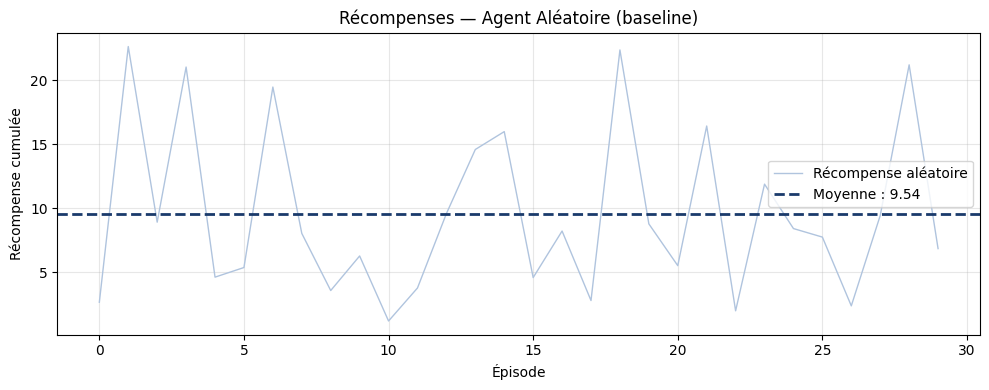

✅ Graphique sauvegardé dans results/baseline_random_agent.png


In [6]:
# On fait plus d'épisodes pour avoir une courbe
env = gym.make('highway-fast-v0')
rewards = []

for _ in range(30):
    obs, _ = env.reset()
    done = truncated = False
    total_reward = 0
    while not (done or truncated):
        obs, reward, done, truncated, _ = env.step(env.action_space.sample())
        total_reward += reward
    rewards.append(total_reward)

env.close()

plt.figure(figsize=(10, 4))
plt.plot(rewards, color='#b0c4de', linewidth=1, label='Récompense aléatoire')
plt.axhline(np.mean(rewards), color='#1a3a6b', linestyle='--', linewidth=2, label=f'Moyenne : {np.mean(rewards):.2f}')
plt.title('Récompenses — Agent Aléatoire (baseline)')
plt.xlabel('Épisode')
plt.ylabel('Récompense cumulée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/baseline_random_agent.png', dpi=150)
plt.show()
print('✅ Graphique sauvegardé dans results/baseline_random_agent.png')